# Sampling Comparison

Ноутбук сравнивает разные solver-методы conditioned sampling в `concat` на 12 равномерно выбранных кейсах из `valid`.

In [25]:
import glob
import json
import os
import platform
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
from diffusers.models.unets.unet_2d import UNet2DModel
from diffusers.training_utils import EMAModel
from functools import partial

from concat.sampler import Sampler
from utils import (
    NpyImageDataset,
    channel_normalize,
    generate_satellite_track_mask,
    get_device,
    make_difference_plot,
    make_plot,
)

if platform.system() == 'Darwin':
    REPO_DIR = '/Users/amir/sciml/diffusion_data_assimilation'
    DATA_ROOT = '/Users/amir/sciml/sea_ice_data'
else:
    REPO_DIR = '/home'
    DATA_ROOT = '/mnt/sciml/a.sadreev/sea_ice_data'

os.chdir(REPO_DIR)

CONCAT_RUN_DIR = None
CHECKPOINT_DIR = os.path.join(REPO_DIR, 'checkpoints')
CHECKPOINT_NAME = 'ema_best_model.pth'

N_CASES = 12
BASE_SEED = 2025
IMAGE_SIZE = (320, 256)
N_TRACKS_RANGE = (0, 0)
N_STEPS = 5
SAMPLING_SETUPS = [
    {'name': 'euler', 'method': 'euler', 'num_timesteps': N_STEPS},
    {'name': 'midpoint', 'method': 'midpoint', 'num_timesteps': N_STEPS},
    {'name': 'heun3', 'method': 'heun3', 'num_timesteps': N_STEPS},
    {'name': 'rk4', 'method': 'rk4', 'num_timesteps': N_STEPS},
    {'name': 'dopri5', 'method': 'dopri5', 'num_timesteps': N_STEPS, 'rtol': 3e-2, 'atol': 3e-3},
]

DEVICE = get_device()

with open(os.path.join(DATA_ROOT, 'train', 'stats.json')) as f:
    stats = json.load(f)
CHANNEL_MEAN = tuple(stats['mean'])
CHANNEL_STD = tuple(stats['std'])

print('repo_dir   =', REPO_DIR)
print('data_root  =', DATA_ROOT)
print('device     =', DEVICE)
print('n_cases    =', N_CASES)
print('base_seed  =', BASE_SEED)
print('setups     =')
print(json.dumps(SAMPLING_SETUPS, indent=2))

repo_dir   = /home
data_root  = /mnt/sciml/a.sadreev/sea_ice_data
device     = cuda
n_cases    = 12
base_seed  = 2025
setups     =
[
  {
    "name": "euler",
    "method": "euler",
    "num_timesteps": 5
  },
  {
    "name": "midpoint",
    "method": "midpoint",
    "num_timesteps": 5
  },
  {
    "name": "heun3",
    "method": "heun3",
    "num_timesteps": 5
  },
  {
    "name": "rk4",
    "method": "rk4",
    "num_timesteps": 5
  },
  {
    "name": "dopri5",
    "method": "dopri5",
    "num_timesteps": 5,
    "rtol": 0.03,
    "atol": 0.003
  }
]


In [26]:
if CONCAT_RUN_DIR is None:
    candidates = sorted(glob.glob(os.path.join(CHECKPOINT_DIR, '**', CHECKPOINT_NAME), recursive=True))
    assert candidates, f'No {CHECKPOINT_NAME} found under {CHECKPOINT_DIR}'
    CONCAT_RUN_DIR = os.path.dirname(candidates[-1])

print('concat_run_dir =', CONCAT_RUN_DIR)

model = UNet2DModel(
    sample_size=IMAGE_SIZE,
    in_channels=7,
    out_channels=2,
    layers_per_block=2,
    block_out_channels=(64, 128, 256, 512, 512),
    down_block_types=(
        'DownBlock2D', 'DownBlock2D', 'DownBlock2D',
        'AttnDownBlock2D', 'DownBlock2D',
    ),
    up_block_types=(
        'UpBlock2D', 'AttnUpBlock2D', 'UpBlock2D',
        'UpBlock2D', 'UpBlock2D',
    ),
)

checkpoint_path = os.path.join(CONCAT_RUN_DIR, CHECKPOINT_NAME)
ema = EMAModel(model.parameters(), decay=0.999)
try:
    ema_state = torch.load(checkpoint_path, map_location='cpu', weights_only=True)
except TypeError:
    ema_state = torch.load(checkpoint_path, map_location='cpu')
ema.load_state_dict(ema_state)
ema.copy_to(model.parameters())
model.eval().to(DEVICE)

sampler = Sampler(model)
print('model loaded from', checkpoint_path)

concat_run_dir = /home/checkpoints/run_20260305_230016
model loaded from /home/checkpoints/run_20260305_230016/ema_best_model.pth


indices       = [   0  796 1592 2388 3185 3981 4777 5573 6370 7166 7962 8759]
clean_images  = (12, 2, 320, 256)
mask_batched  = (12, 1, 320, 256)
observed      = (12, 2, 320, 256)
mask coverage = 0.0


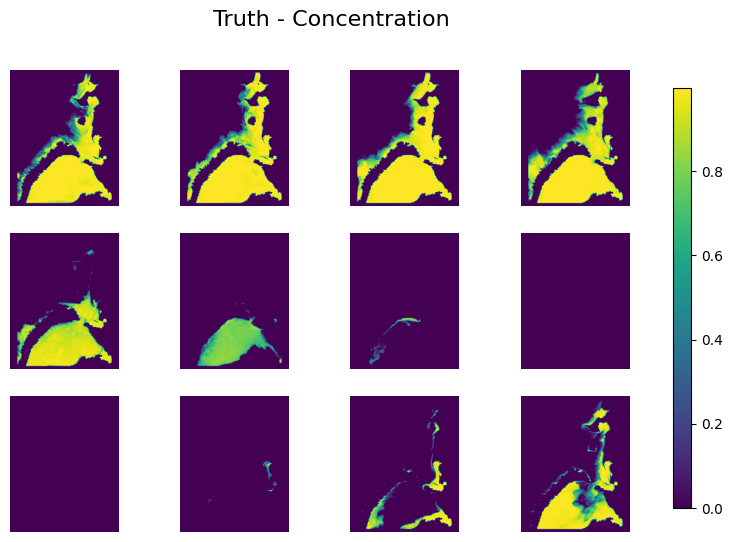

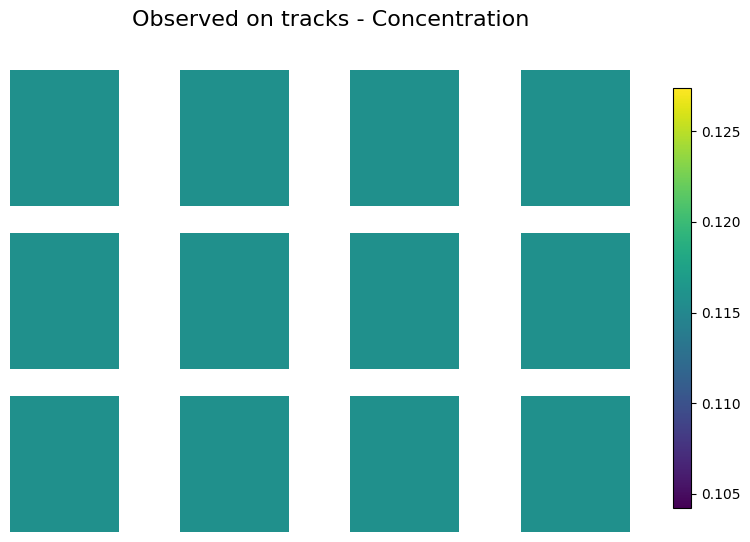

In [27]:
transform = partial(channel_normalize, channel_mean=CHANNEL_MEAN, channel_std=CHANNEL_STD)

val_dataset = NpyImageDataset(
    folder=os.path.join(DATA_ROOT, 'valid'),
    transform=transform,
    preload=False,
    mmap_mode='r',
)
indices = np.linspace(0, len(val_dataset) - 1, N_CASES, dtype=int)
clean_images = torch.stack([val_dataset[i] for i in indices]).to(DEVICE)

valid_mask = np.load(os.path.join(DATA_ROOT, 'mask_padding.npy')).astype(np.float32)
np.random.seed(BASE_SEED)
mask_np = generate_satellite_track_mask(
    image_size=IMAGE_SIZE,
    batch_size=N_CASES,
    valid_mask=valid_mask,
    n_tracks_range=N_TRACKS_RANGE,
)
mask_batched = torch.from_numpy(mask_np).unsqueeze(1).to(DEVICE)
observed = clean_images * mask_batched

truth_cpu = clean_images.detach().cpu()
mask_cpu = mask_batched.detach().cpu()
mask_2ch = mask_cpu.expand(-1, truth_cpu.shape[1], -1, -1)

print('indices       =', indices)
print('clean_images  =', tuple(clean_images.shape))
print('mask_batched  =', tuple(mask_batched.shape))
print('observed      =', tuple(observed.shape))
print('mask coverage =', float(mask_batched.mean().item()))

make_plot(truth_cpu, CHANNEL_MEAN, CHANNEL_STD, N_CASES, title='Truth - Concentration')
make_plot(observed.detach().cpu(), CHANNEL_MEAN, CHANNEL_STD, N_CASES, title='Observed on tracks - Concentration')

In [28]:
results = []
for setup in SAMPLING_SETUPS:
    torch.manual_seed(BASE_SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(BASE_SEED)

    started = time.perf_counter()
    predictions = sampler.sample_conditioned(
        mask=mask_batched,
        observed=observed,
        size=IMAGE_SIZE,
        num_timesteps=setup['num_timesteps'],
        device=DEVICE,
        method=setup['method'],
        rtol=setup.get('rtol', 1e-3),
        atol=setup.get('atol', 1e-4),
    )
    elapsed = time.perf_counter() - started

    predictions = predictions.detach().cpu()
    case_rmse = torch.sqrt(((predictions - truth_cpu) ** 2).mean(dim=(1, 2, 3)))
    masked_case_rmse = torch.sqrt(
        (((predictions - truth_cpu) ** 2 * mask_2ch).sum(dim=(1, 2, 3)) / mask_2ch.sum(dim=(1, 2, 3)).clamp(min=1.0))
    )

    results.append({
        'name': setup['name'],
        'predictions': predictions,
        'elapsed_sec': elapsed,
        'rmse_mean': float(case_rmse.mean().item()),
        'rmse_std': float(case_rmse.std(unbiased=False).item()),
        'masked_rmse_mean': float(masked_case_rmse.mean().item()),
        'masked_rmse_std': float(masked_case_rmse.std(unbiased=False).item()),
        'case_rmse': case_rmse.tolist(),
        'masked_case_rmse': masked_case_rmse.tolist(),
    })

summary = [
    {
        'name': result['name'],
        'elapsed_sec': result['elapsed_sec'],
        'rmse_mean': result['rmse_mean'],
        'rmse_std': result['rmse_std'],
        'masked_rmse_mean': result['masked_rmse_mean'],
        'masked_rmse_std': result['masked_rmse_std'],
    }
    for result in results
]
summary = sorted(summary, key=lambda row: row['rmse_mean'])
print(json.dumps(summary, indent=2))

[
  {
    "name": "euler",
    "elapsed_sec": 1.4318972397595644,
    "rmse_mean": 1.0664663314819336,
    "rmse_std": 0.3855385184288025,
    "masked_rmse_mean": 0.0,
    "masked_rmse_std": 0.0
  },
  {
    "name": "midpoint",
    "elapsed_sec": 2.834219259209931,
    "rmse_mean": 1.1316421031951904,
    "rmse_std": 0.3653045892715454,
    "masked_rmse_mean": 0.0,
    "masked_rmse_std": 0.0
  },
  {
    "name": "heun3",
    "elapsed_sec": 4.132228692062199,
    "rmse_mean": 1.142053484916687,
    "rmse_std": 0.3709588646888733,
    "masked_rmse_mean": 0.0,
    "masked_rmse_std": 0.0
  },
  {
    "name": "rk4",
    "elapsed_sec": 5.512058349326253,
    "rmse_mean": 1.1436258554458618,
    "rmse_std": 0.37097644805908203,
    "masked_rmse_mean": 0.0,
    "masked_rmse_std": 0.0
  },
  {
    "name": "dopri5",
    "elapsed_sec": 8.997142779640853,
    "rmse_mean": 1.2466078996658325,
    "rmse_std": 0.39620518684387207,
    "masked_rmse_mean": 0.0,
    "masked_rmse_std": 0.0
  }
]


euler


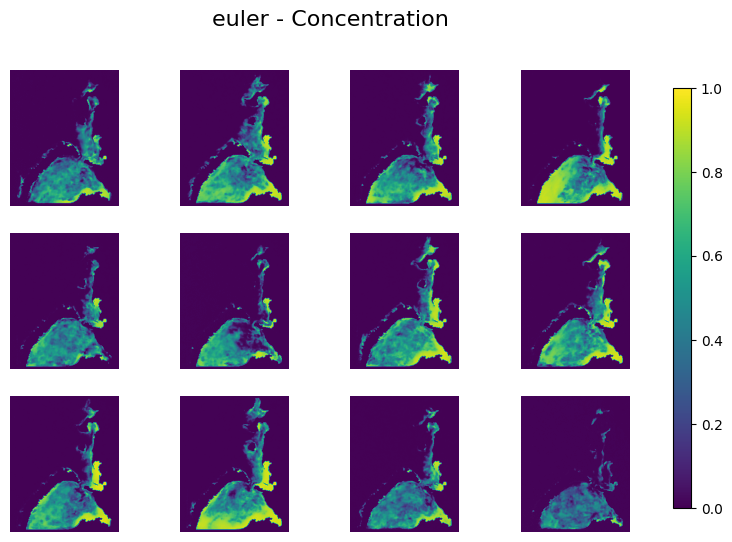

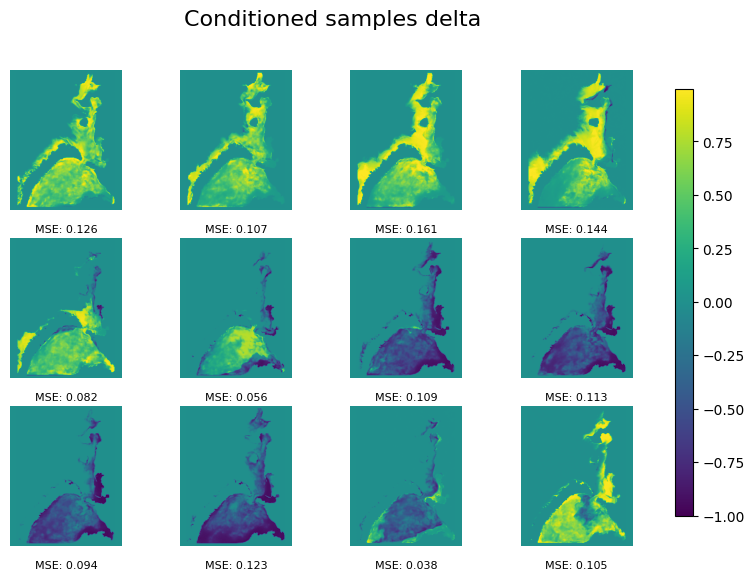

midpoint


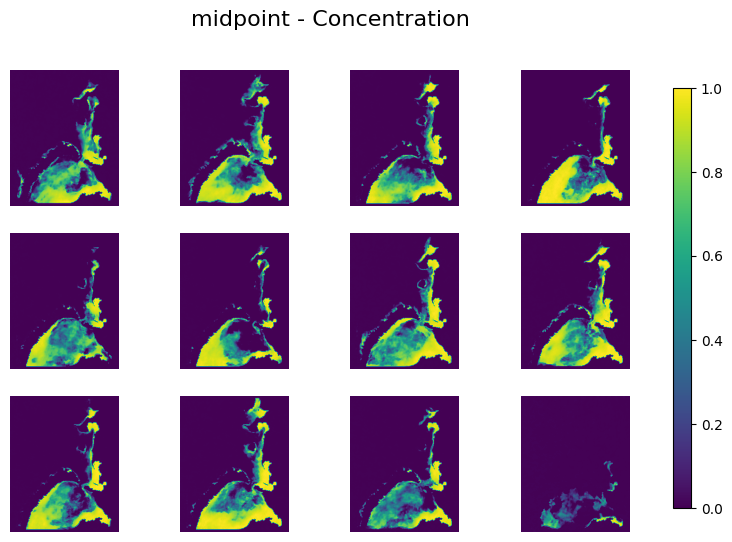

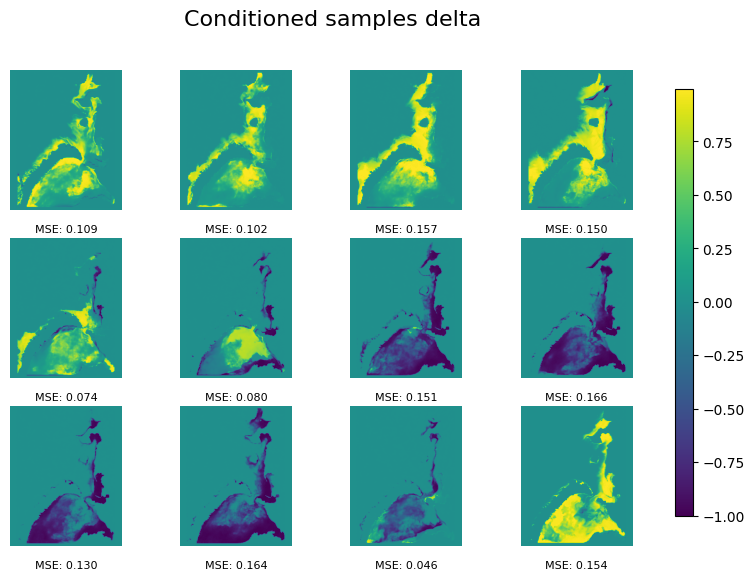

heun3


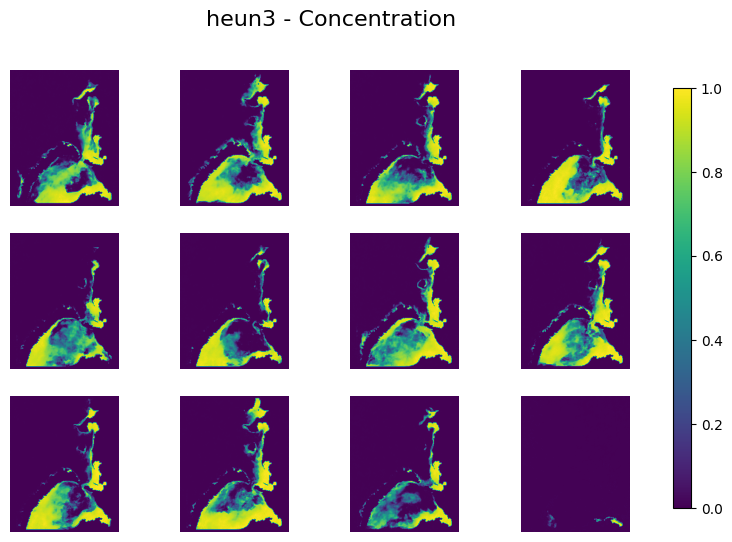

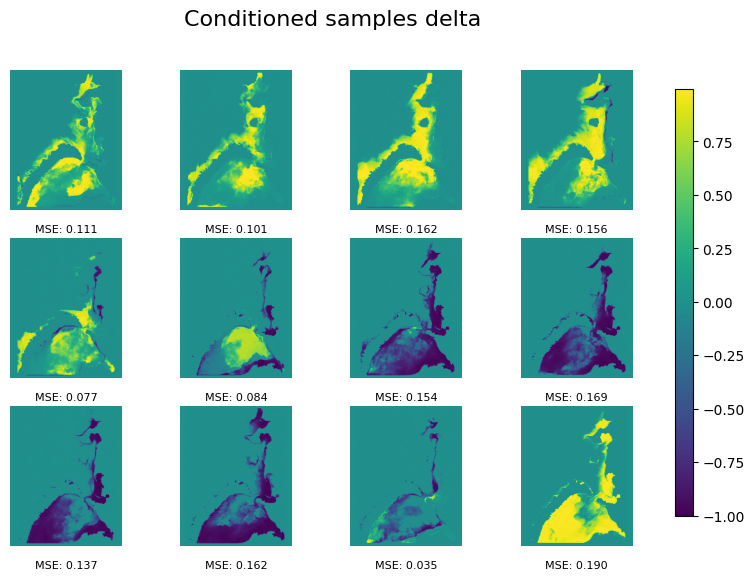

rk4


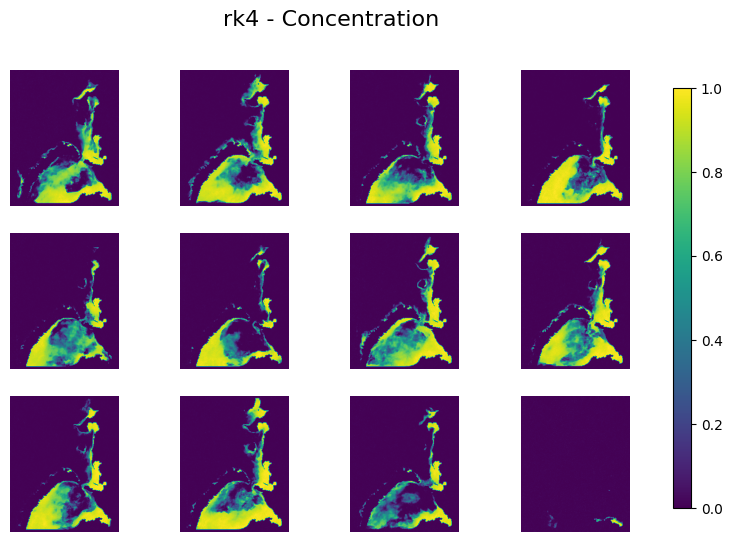

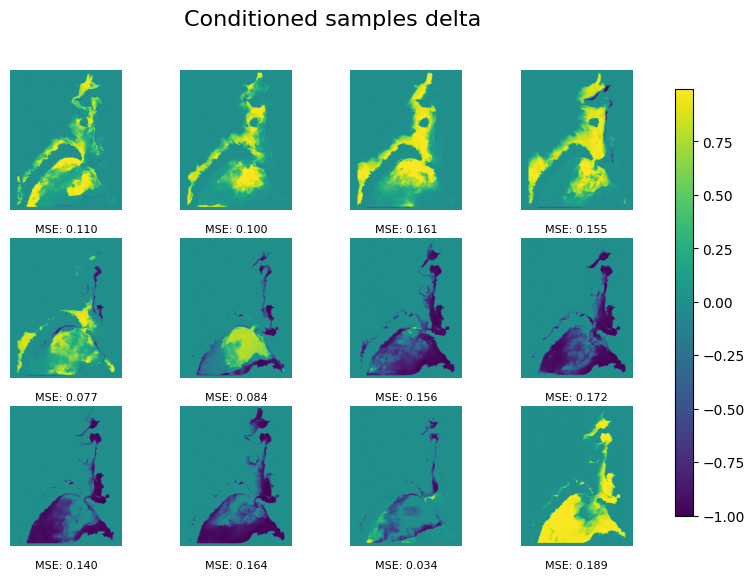

dopri5


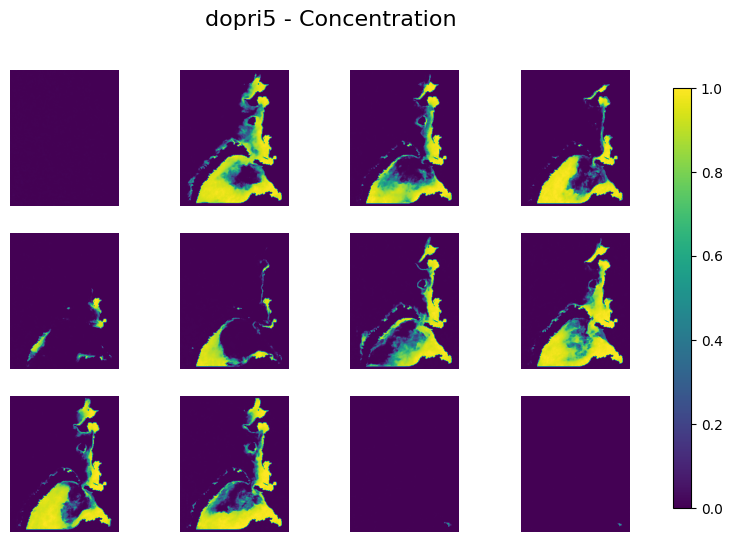

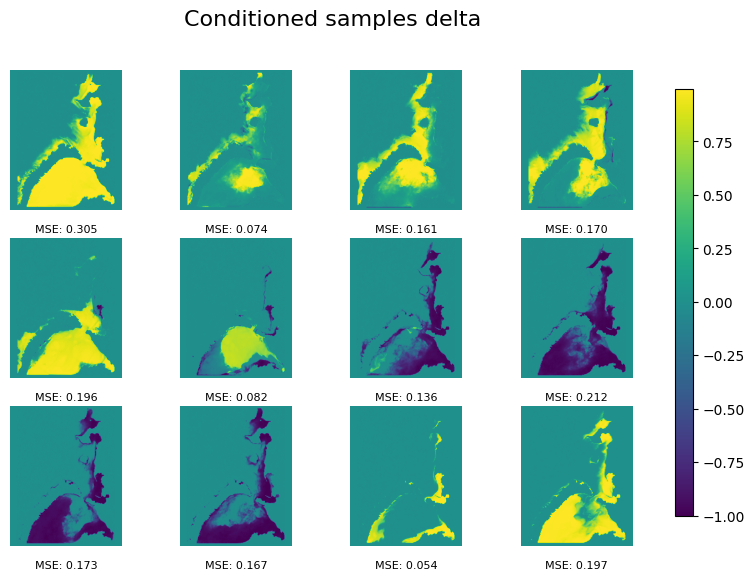

In [29]:
water_mask = torch.from_numpy(valid_mask)
for result in results:
    print(result['name'])
    make_plot(result['predictions'], CHANNEL_MEAN, CHANNEL_STD, N_CASES, title=f"{result['name']} - Concentration")
    make_difference_plot(truth_cpu, result['predictions'], CHANNEL_MEAN, CHANNEL_STD, N_CASES, land_mask=water_mask, title=result['name'])

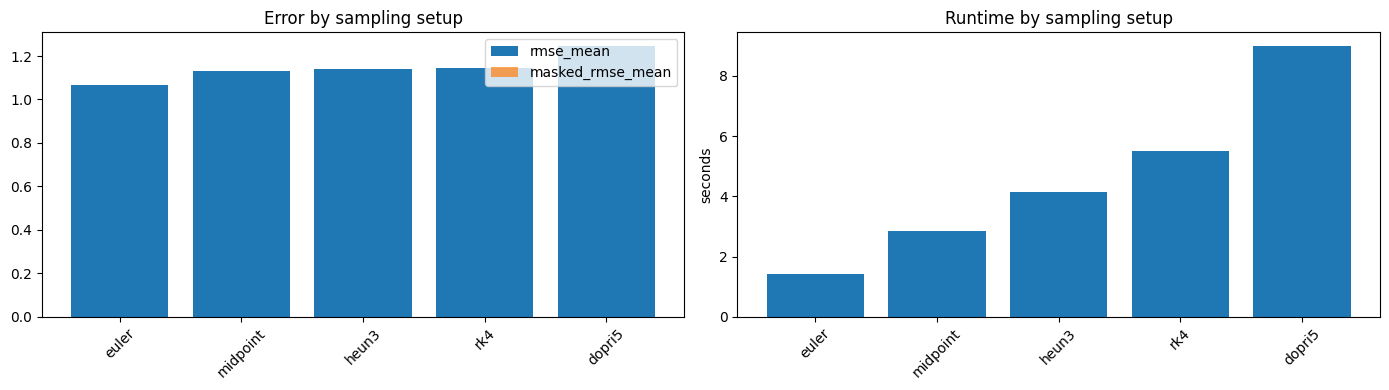

In [30]:
names = [item['name'] for item in summary]
rmse_mean = [item['rmse_mean'] for item in summary]
masked_rmse_mean = [item['masked_rmse_mean'] for item in summary]
elapsed_sec = [item['elapsed_sec'] for item in summary]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(names, rmse_mean, label='rmse_mean')
axes[0].bar(names, masked_rmse_mean, alpha=0.7, label='masked_rmse_mean')
axes[0].set_title('Error by sampling setup')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()

axes[1].bar(names, elapsed_sec)
axes[1].set_title('Runtime by sampling setup')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylabel('seconds')

plt.tight_layout()